<a href="https://colab.research.google.com/github/vananhnt2801/Carbon-Price-Forecasting/blob/main/%5B19_08_26_Reimplementation%5D_CTr2L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving shanghai.csv to shanghai.csv
Saving guangdong.csv to guangdong.csv


In [2]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: []


In [3]:
!pip install -q dtaidistance
import dtaidistance
import sklearn
import pandas as pd
import numpy as np
print("Tất cả import thành công, môi trường sạch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 40.4 MB/s eta 0:00:00
Tất cả import thành công, môi trường sạch


In [4]:
import pandas as pd
import numpy as np

def load_and_clean(path):
    d = pd.read_csv(path)
    d.columns = [c.strip() for c in d.columns]
    rename_map = {c: 'ProductionCoal' for c in d.columns if c.lower() == 'production(coal)'}
    d = d.rename(columns=rename_map)
    d['TradingDate'] = pd.to_datetime(d['TradingDate'], format='%Y/%m/%d')
    d = d.sort_values('TradingDate').reset_index(drop=True)
    return d

guangdong = load_and_clean('guangdong.csv')   # source domain (pilot, nhiều data)
shanghai  = load_and_clean('shanghai.csv')    # target domain (emerging, ít data)

print("Guangdong:", guangdong.shape)
print("Shanghai:", shanghai.shape)
guangdong.head()

Guangdong: (1477, 12)
Shanghai: (491, 12)


,TradingDate,LowPrice,Volume,n,Margin Trading,ProductionCoal,AQI,PMI,USD,log,garch,vola
0,2016-05-13,15.60,300985.0,0.089385,4.820000e+11,3781,110,50.1,652.46,0.085614,0.074720,0.063273
1,2016-05-16,14.04,1130.0,0.026282,4.820000e+11,3781,63,50.1,653.43,0.025943,0.060360,0.062490
2,2016-05-18,14.41,150012.0,-0.063086,4.770000e+11,3781,100,50.1,652.16,-0.065163,0.062683,0.067066
3,2016-05-19,13.50,210.0,0.043333,4.770000e+11,3781,59,50.1,655.31,0.042421,0.057960,0.051709
4,2016-05-20,15.65,200000.0,0.000000,4.760000e+11,3781,59,50.1,655.10,0.000000,0.047517,0.049942


In [5]:
from sklearn.preprocessing import StandardScaler

FEAT_COLS = ['LowPrice', 'Volume', 'n', 'PMI', 'Margin Trading', 'ProductionCoal', 'USD', 'AQI', 'garch']
TARGET_COL = 'vola'
L = 10   # cửa sổ lookback

def make_sequences(df, feat_cols, target_col, L=10):
    scaler = StandardScaler()
    feats = scaler.fit_transform(df[feat_cols].values)
    target = df[target_col].values
    X, y = [], []
    for i in range(L, len(df)):
        X.append(feats[i-L:i])
        y.append(target[i])
    return np.array(X), np.array(y), scaler

X_gd, y_gd, scaler_gd = make_sequences(guangdong, FEAT_COLS, TARGET_COL, L=L)
X_sh, y_sh, scaler_sh = make_sequences(shanghai, FEAT_COLS, TARGET_COL, L=L)
print("Guangdong sequences:", X_gd.shape, "| Shanghai sequences:", X_sh.shape)

Guangdong sequences: (1467, 10, 9) | Shanghai sequences: (481, 10, 9)


In [6]:
def split_80_5_15(X, y):
    n = len(X)
    train_end = int(n * 0.80)
    val_end   = int(n * 0.85)
    return (X[:train_end], y[:train_end],
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:])

Xgd_tr, ygd_tr, Xgd_va, ygd_va, Xgd_te, ygd_te = split_80_5_15(X_gd, y_gd)
Xsh_tr, ysh_tr, Xsh_va, ysh_va, Xsh_te, ysh_te = split_80_5_15(X_sh, y_sh)

print(f"Guangdong -> train {len(Xgd_tr)} val {len(Xgd_va)} test {len(Xgd_te)}")
print(f"Shanghai  -> train {len(Xsh_tr)} val {len(Xsh_va)} test {len(Xsh_te)}")

Guangdong -> train 1173 val 73 test 221
Shanghai  -> train 384 val 24 test 73


In [18]:
def build_rnn(n_features, cell='GRU', units1=5, units2=5):
    Cell = layers.GRU if cell == 'GRU' else layers.LSTM
    inputs = layers.Input(shape=(None, n_features))
    x = Cell(units1, return_sequences=True, name='G1')(inputs)
    x = Cell(units2, name='G2')(x)
    out = layers.Dense(1, activation='softplus', name='D1')(x)   # THÊM activation='softplus' -> luôn ra số dương
    m = models.Model(inputs, out)
    m.compile(optimizer='adam', loss='mse')
    return m

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

def build_rnn(n_features, cell='GRU', units1=5, units2=5):
    Cell = layers.GRU if cell == 'GRU' else layers.LSTM
    inputs = layers.Input(shape=(None, n_features))
    x = Cell(units1, return_sequences=True, name='G1')(inputs)
    x = Cell(units2, name='G2')(x)
    out = layers.Dense(1, name='D1')(x)
    m = models.Model(inputs, out)
    m.compile(optimizer='adam', loss='mse')
    return m

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    return rmse, mae, medae

results = {}
early_stop = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

for cell_name in ['LSTM', 'GRU']:
    m = build_rnn(len(FEAT_COLS), cell=cell_name)
    m.fit(Xgd_tr, ygd_tr, validation_data=(Xgd_va, ygd_va),
          epochs=150, batch_size=32, verbose=0, callbacks=[early_stop])
    pred = m.predict(Xgd_te, verbose=0).flatten()
    results[cell_name] = evaluate(ygd_te, pred)
    if cell_name == 'GRU':
        baseline_gru_model = m   # giữ lại để dùng cho CTr2L ở Bước 7

for name, (rmse, mae, medae) in results.items():
    print(f"{name:10s} RMSE={rmse:.5f} MAE={mae:.5f} MedAE={medae:.5f}")

LSTM       RMSE=0.01948 MAE=0.01467 MedAE=0.01060
GRU        RMSE=0.15832 MAE=0.12907 MedAE=0.10532


In [20]:
import pandas as pd

table4 = pd.DataFrame(results, index=['RMSE', 'MAE', 'MedAE']).T
print(table4.round(5))

         RMSE      MAE    MedAE
LSTM  0.01948  0.01467  0.01060
GRU   0.15832  0.12907  0.10532


In [21]:
g1_layer = baseline_gru_model.get_layer('G1')
g1_layer.trainable = False

inputs2 = layers.Input(shape=(None, len(FEAT_COLS)))
g1_out = g1_layer(inputs2)
g2_new = layers.GRU(10, name='G2_new')(g1_out)
out_new = layers.Dense(1, name='D1_new')(g2_new)

ctr2l_model = models.Model(inputs2, out_new)
ctr2l_model.compile(optimizer='adam', loss='mse')

es_ctr2l = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)  # callback RIÊNG
ctr2l_model.fit(Xsh_tr, ysh_tr, validation_data=(Xsh_va, ysh_va),
                 epochs=150, batch_size=32, verbose=1, callbacks=[es_ctr2l])

pred_ctr2l = ctr2l_model.predict(Xsh_te, verbose=0).flatten()
rmse_c, mae_c, medae_c = evaluate(ysh_te, pred_ctr2l)
print(f"CTr2L RMSE={rmse_c:.5f} MAE={mae_c:.5f} MedAE={medae_c:.5f}")

# Kiểm tra nhanh xem model có "sập" không:
print("y thật (5 mẫu đầu):", ysh_te[:5])
print("y dự đoán (5 mẫu đầu):", pred_ctr2l[:5])

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - loss: 0.0469 - val_loss: 0.0340
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0137 - val_loss: 0.0202
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0083 - val_loss: 0.0112
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0069 - val_loss: 0.0056
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 0.0035
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0043 - val_loss: 0.0026
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036 - val_loss: 0.0023
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/ste

In [22]:
baseline_sh_only = build_rnn(len(FEAT_COLS), cell='GRU')
es_baseline = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)  # callback RIÊNG
baseline_sh_only.fit(Xsh_tr, ysh_tr, validation_data=(Xsh_va, ysh_va),
                      epochs=150, batch_size=32, verbose=0, callbacks=[es_baseline])
pred_baseline_sh = baseline_sh_only.predict(Xsh_te, verbose=0).flatten()
rmse_b, mae_b, medae_b = evaluate(ysh_te, pred_baseline_sh)
print(f"Baseline (no transfer) RMSE={rmse_b:.5f} MAE={mae_b:.5f} MedAE={medae_b:.5f}")
print(f"CTr2L                  RMSE={rmse_c:.5f} MAE={mae_c:.5f} MedAE={medae_c:.5f}")

Baseline (no transfer) RMSE=0.04129 MAE=0.03429 MedAE=0.03433
CTr2L                  RMSE=0.06056 MAE=0.05411 MedAE=0.05278


In [23]:
np.random.seed(42)
noise_rmses = []

for trial in range(10):
    X_noise = np.random.randn(*Xgd_tr.shape)
    y_noise = np.random.randn(*ygd_tr.shape) * ygd_tr.std() + ygd_tr.mean()

    noise_model = build_rnn(len(FEAT_COLS), cell='GRU')
    noise_model.fit(X_noise, y_noise, epochs=50, batch_size=32, verbose=0)

    g1_noise = noise_model.get_layer('G1')
    g1_noise.trainable = False
    inputs3 = layers.Input(shape=(None, len(FEAT_COLS)))
    g1n_out = g1_noise(inputs3)
    g2n_new = layers.GRU(10, name=f'G2_noise_{trial}')(g1n_out)
    out3 = layers.Dense(1, name=f'D1_noise_{trial}')(g2n_new)
    noise_ctr2l = models.Model(inputs3, out3)
    noise_ctr2l.compile(optimizer='adam', loss='mse')

    es_noise = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)  # callback RIÊNG mỗi trial
    noise_ctr2l.fit(Xsh_tr, ysh_tr, validation_data=(Xsh_va, ysh_va),   # ĐÃ THÊM validation_data
                     epochs=150, batch_size=32, verbose=0, callbacks=[es_noise])

    pred_noise = noise_ctr2l.predict(Xsh_te, verbose=0).flatten()
    rmse_n = np.sqrt(mean_squared_error(ysh_te, pred_noise))
    noise_rmses.append(rmse_n)
    print(f"Trial {trial+1}/10 - Noise CTr2L RMSE = {rmse_n:.5f}")

print(f"\n[Noise CTr2L] median RMSE = {np.median(noise_rmses):.5f}")
print(f"[CTr2L thật]  RMSE = {rmse_c:.5f}")

Trial 1/10 - Noise CTr2L RMSE = 0.01526
Trial 2/10 - Noise CTr2L RMSE = 0.03477
Trial 3/10 - Noise CTr2L RMSE = 0.01876
Trial 4/10 - Noise CTr2L RMSE = 0.03106
Trial 5/10 - Noise CTr2L RMSE = 0.02751
Trial 6/10 - Noise CTr2L RMSE = 0.01720
Trial 7/10 - Noise CTr2L RMSE = 0.02185
Trial 8/10 - Noise CTr2L RMSE = 0.01978
Trial 9/10 - Noise CTr2L RMSE = 0.04475
Trial 10/10 - Noise CTr2L RMSE = 0.02468

[Noise CTr2L] median RMSE = 0.02326
[CTr2L thật]  RMSE = 0.06056


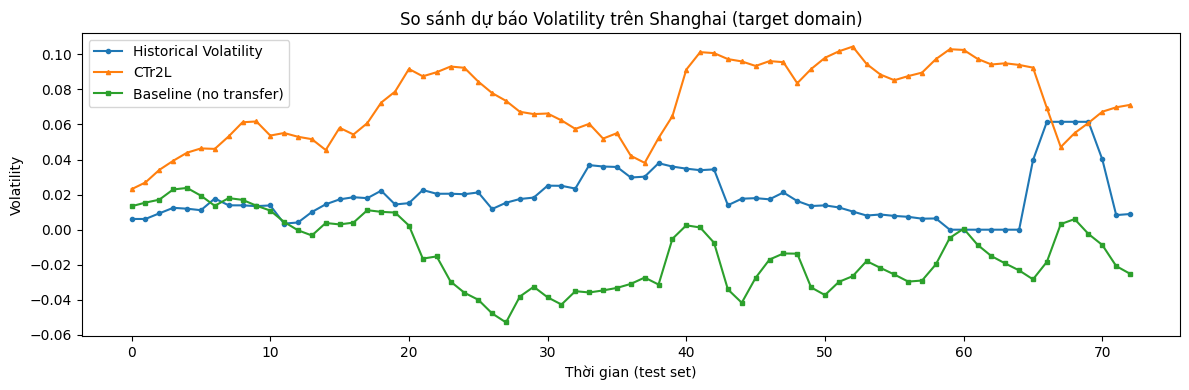

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ysh_te, label='Historical Volatility', marker='o', markersize=3)
plt.plot(pred_ctr2l, label='CTr2L', marker='^', markersize=3)
plt.plot(pred_baseline_sh, label='Baseline (no transfer)', marker='s', markersize=3)
plt.legend(); plt.title('So sánh dự báo Volatility trên Shanghai (target domain)')
plt.xlabel('Thời gian (test set)'); plt.ylabel('Volatility')
plt.tight_layout(); plt.show()

In [25]:
from dtaidistance import dtw
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

source_series = guangdong['vola'].values.astype(np.double)
target_series = shanghai['vola'].values.astype(np.double)
dtw_dist = dtw.distance(source_series, target_series)

# Lasso: dùng feature nguồn (Guangdong) dự đoán target (Shanghai) - căn chỉnh độ dài
min_len = min(len(guangdong), len(shanghai))
X_lasso = guangdong[FEAT_COLS].values[:min_len]
y_lasso = shanghai['vola'].values[:min_len]

lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_lasso, y_lasso)
y_lasso_pred = lasso.predict(X_lasso)
r2_lasso = max(r2_score(y_lasso, y_lasso_pred), 1e-6)

v_factor = dtw_dist / r2_lasso
print(f"DTW(Guangdong, Shanghai) = {dtw_dist:.4f}")
print(f"R2_Lasso = {r2_lasso:.4f}")
print(f"Transferability factor v = {v_factor:.4f}")
print("→ v càng nhỏ, CTr2L từ Guangdong sang Shanghai càng phù hợp")

DTW(Guangdong, Shanghai) = 0.4608
R2_Lasso = 0.2333
Transferability factor v = 1.9757
→ v càng nhỏ, CTr2L từ Guangdong sang Shanghai càng phù hợp
